# ANALYSIS OF SCORES

In [4]:
import sys, pathlib
try:
    sys.path.insert(0, str(pathlib.Path.cwd().parent))
except ImportError as e:
    print(f"Error importing src: {e}")
from src.score import Score
from src.linear_predictor import LinearPredictor
import sbmlnetwork as sb
import os
import src.constants as cn
import numpy as np  # type: ignore
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
from src.biomodels_iterator import BiomodelsIterator
from src.trajectory import Trajectory
from src.trajectory_collection import TrajectoryCollection
from src.multiple_linear_predictor import MultipleLinearPredictor
import tellurium as te

# Helpers

In [ ]:
def evaluateMlp(model_num, num_splits=2, is_slow_subspace: bool = False,
                min_num_point_per_segment: int = 5, **kwargs):
    if not isinstance(num_splits, list):
        num_splits = [num_splits]
    trajectory = Trajectory.makeBiomodel(model_num=model_num, end_time=10)
    tcs = [TrajectoryCollection.autoSplit(trajectory, num_split=n,
            is_slow_subspace=is_slow_subspace, 
            min_num_point_per_segment=min_num_point_per_segment
            ) for n in num_splits]
    #
    lp = LinearPredictor(trajectory)
    lp.plotPrediction(**kwargs)
    #
    for tc in tcs:
        mlp = MultipleLinearPredictor(tc, is_slow_subspace=is_slow_subspace)
        mlp.plotPrediction(**kwargs)

# Quadratic Networks

Below is Yeejee's network.

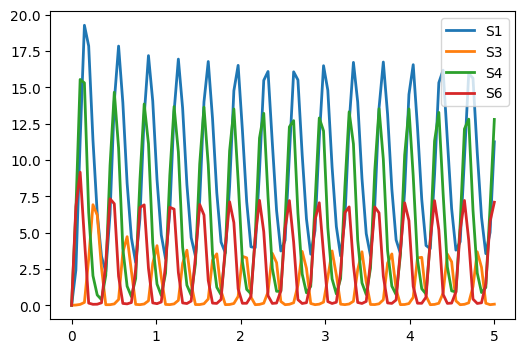

In [5]:
YJ_NET = """
$S8 -> S6; k0*S8
S1 -> S3; k2*S1
S3 + S6 ->; k4*S3*S6
S4 -> S1; k5*S4
S6 -> S6 + S4; k6*S6

k0 = 24; k2 = 15; k3 = 54; k4 = 315
k5 = 24; k6 = 53
S8 = 6.0
"""
rr = te.loada(YJ_NET)
DATA_YJ = rr.simulate(0, 5, 100, selections=['time', 'S1', 'S3', 'S4', 'S6'])
rr.plot()

False


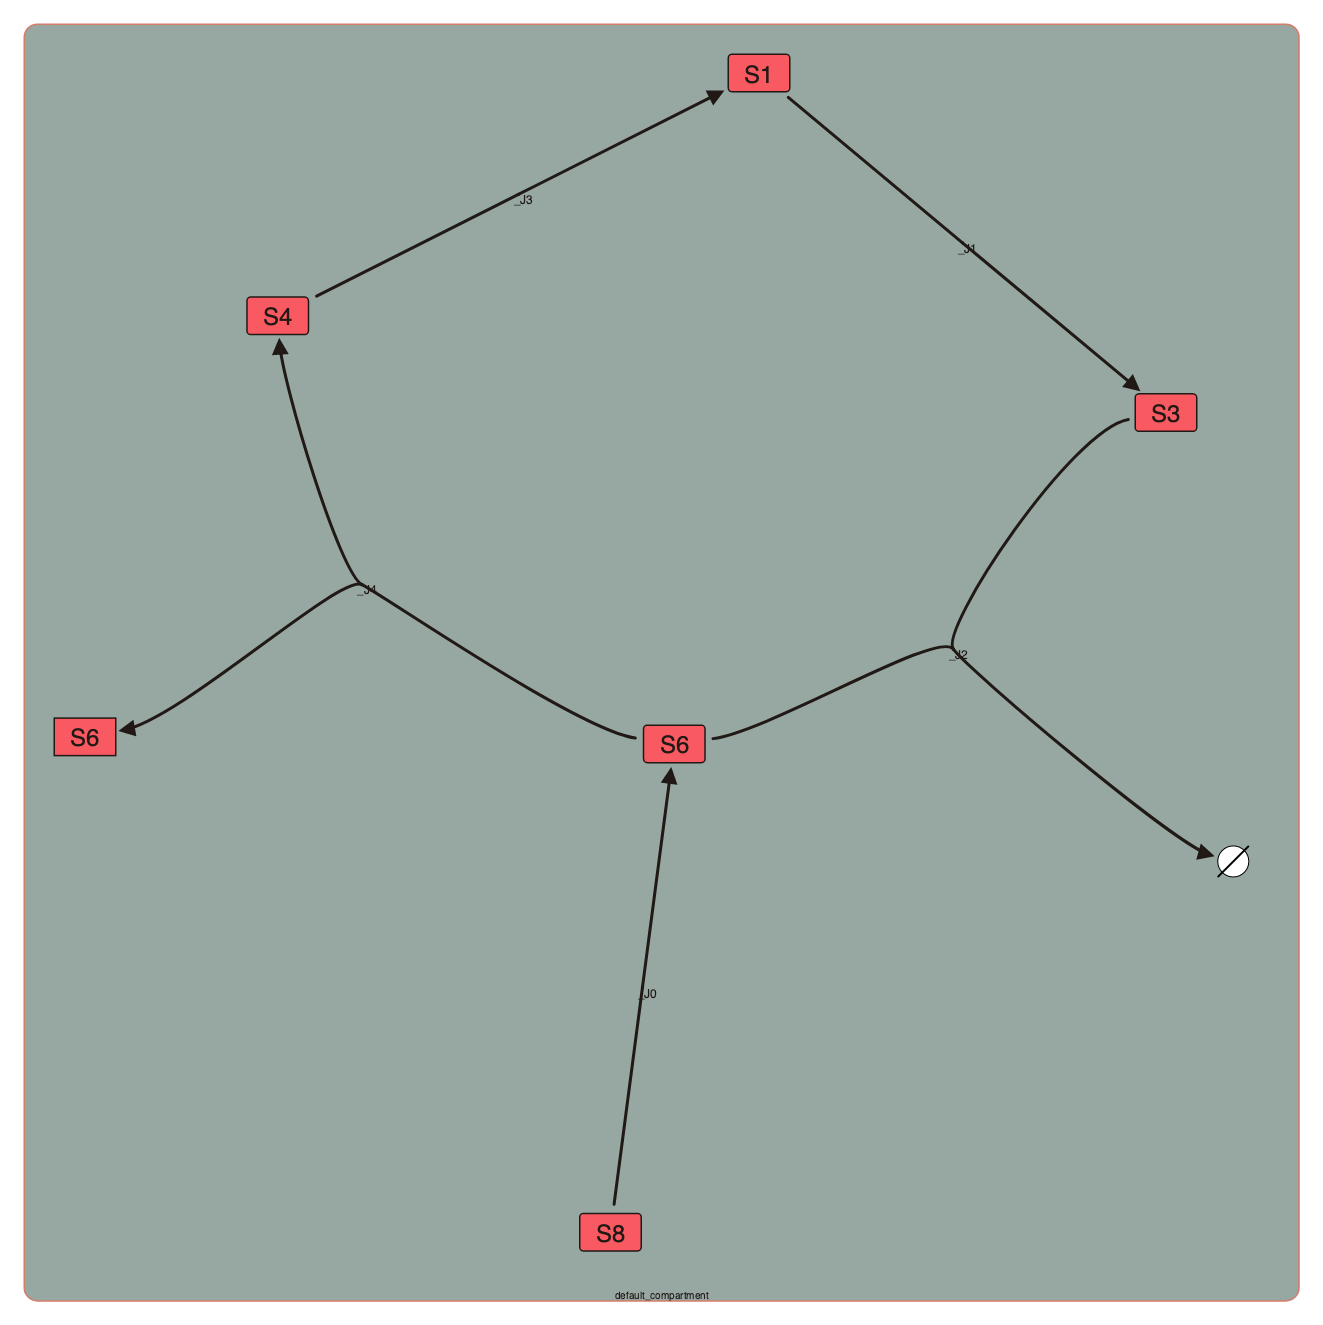

In [23]:
def draw(ant_str: str):
    rr = te.loada(ant_str)
    sbml_str = rr.getSBML()
    net = sb.load(sbml_str)
    
    # Render the network and save a PNG
    print(net.set_size((50.0, 50.0)))
    net.draw()

draw(YJ_NET)

Below is a simplification of the network Yeejee discovered

In [ ]:
Need more accuracy in constants?

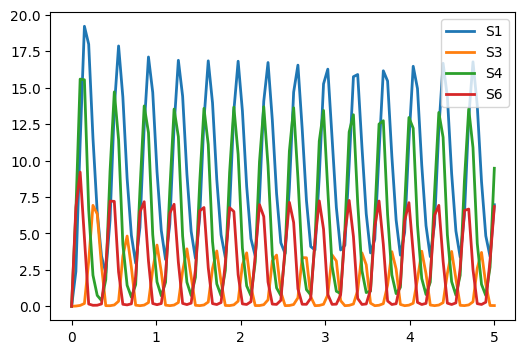

False


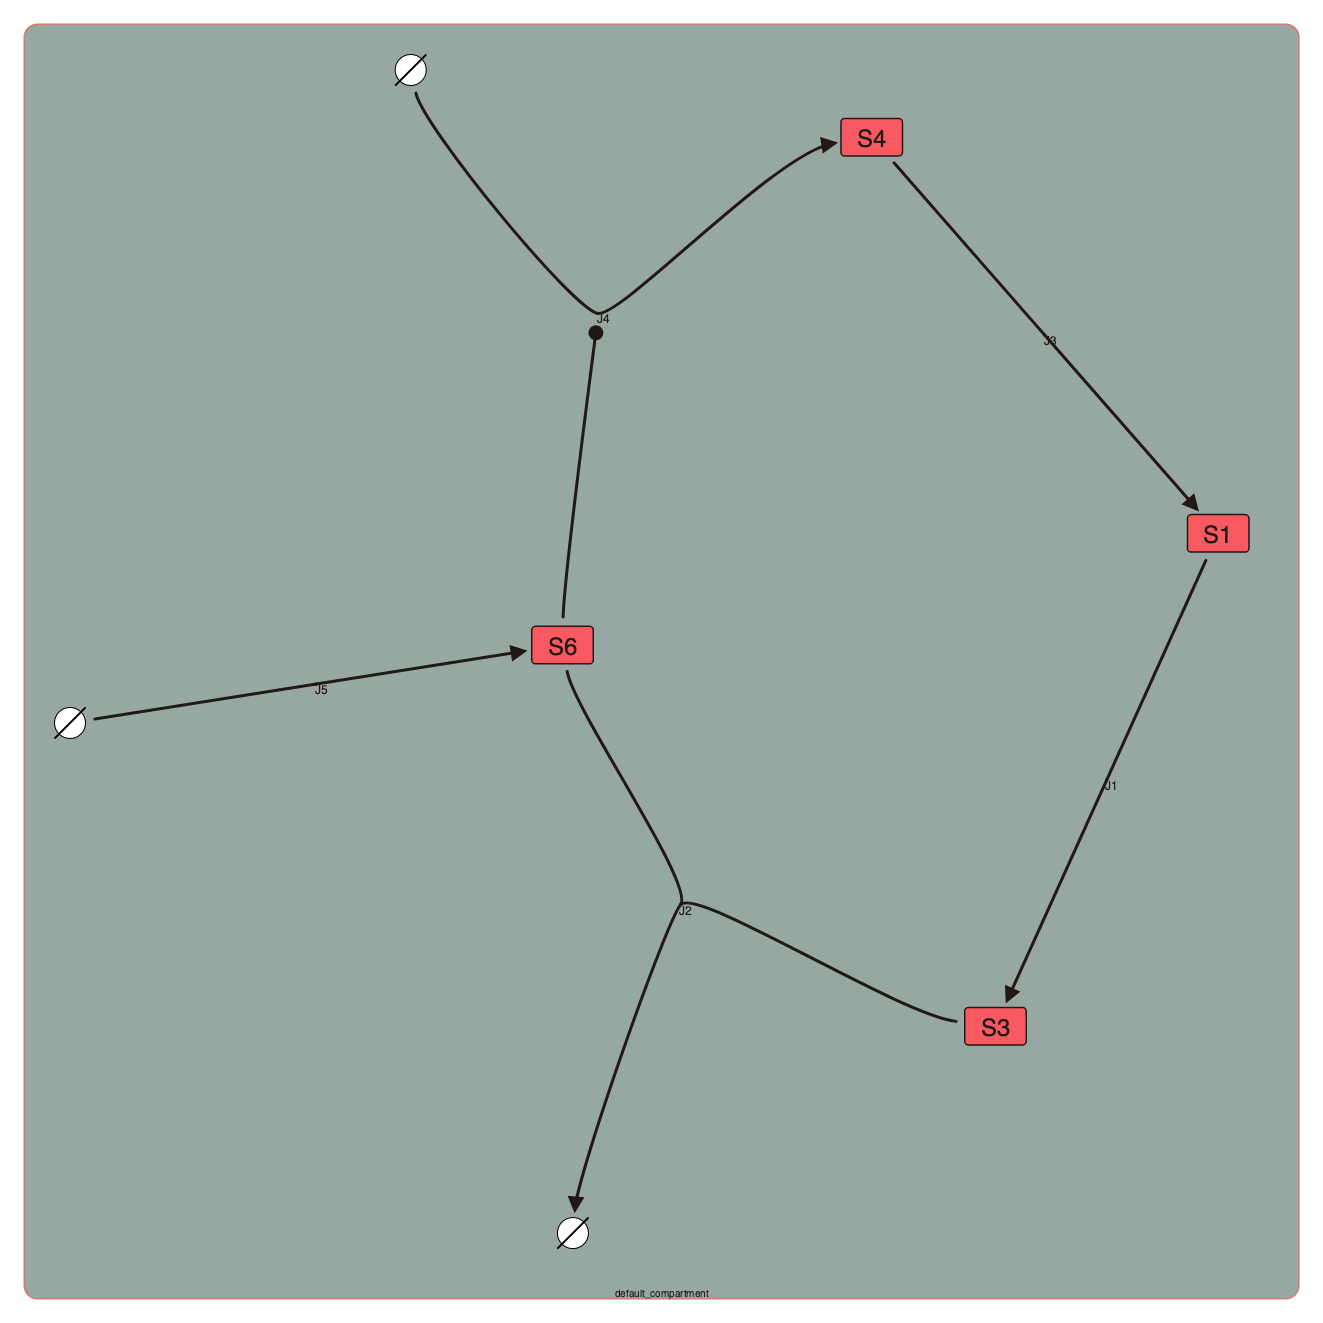

In [24]:
import tellurium as te
model = """
J1: S1 -> S3; 2.494728*S1*S8
J2: S3 + S6 -> ; 312.753091*S3*S6
J3: S4 -> S1; 3.957946*S4*S8
J4: -> S4; 8.787850*S6*S8
J5: -> S6; 3.993558*S8*S8

$S8 = 6
"""
rr = te.loada(model)
DATA_DISC = rr.simulate(0, 5, 100, selections=['time', 'S1', 'S3', 'S4', 'S6'])
rr.plot()
draw(model)

In [ ]:
icol = 2
np.sum((DATA_YJ[1:, icol]- DATA_DISC[1:, icol])**2)/(np.std(DATA_YJ[1:, icol])*np.std(DATA_DISC[1:, icol]))

In [ ]:
icol = 1
DATA_YJ[:, icol] - DATA_DISC[:, icol]

In [ ]:
for icol in range(1, len(DATA_YJ.colnames)): 
    plt.figure()
    plt.scatter(DATA_YJ[:, icol], DATA_DISC[:, icol])
    rsq = np.sum((DATA_YJ[1:, icol]- DATA_DISC[1:, icol])**2)/(np.std(DATA_YJ[1:, icol])*np.std(DATA_DISC[1:, icol]))
    plt.title(f"{DATA_YJ.colnames[icol]}: {rsq}")

In [ ]:
# Plot variables separately
for icol in range(1, len(DATA_YJ.colnames)): 
    plt.figure()
    plt.scatter(DATA_YJ[:, 0], DATA_YJ[:, icol])
    plt.plot(DATA_YJ[:, 0], DATA_DISC[:, icol], linestyle='--')
    plt.title(f"{DATA_YJ.colnames[icol]}")
    plt.xlabel("time")

# Timeseries Plots

In [ ]:
def plotModel(model_num, start_time=0, end_time=None, **kwargs):
    predictor = LinearPredictor.makeFromBiomodels(model_num=model_num, 
                start_time=start_time, end_time=end_time, num_step=-1, num_point=100,
                jacobian_selection=cn.JAC_FITTED)
    df = predictor.score()
    score_p95 = df.loc[0, 'p95']
    _ = predictor.plotPrediction(title=f"Model {model_num}, p95={score_p95:.2f}", **kwargs)


plotModel(115, start_time=5, end_time=6, legend=False)

In [ ]:
iterator = BiomodelsIterator(
            is_report=False,
            #excluded_models=excluded_models,
            first_model_num=1,
            last_model_num=20)
for item in iterator:
    if item.model_num in [11, 12, 14, 19, 48]:
        print(f"Excluding model {item.model_num}")
        continue
    try:
        print(f"Processing {item.model_num}")
        plotModel(item.model_num)
    except:
        print(f"Failed on model {item.model_num}")
    

# Splitting

In [ ]:
iterator = BiomodelsIterator(
            is_report=False,
            #excluded_models=excluded_models,
            first_model_num=1,
            last_model_num=4)
for item in iterator:
    if item.model_num in [11, 13, 14, 19, 38, 41, 48, 50]:
        print(f"Excluding model {item.model_num}")
        continue
    try:
        print(f"Processing {item.model_num}")
        evaluateMlp(item.model_num, num_splits=[1, 2], legend=False,  # type: ignore
                    min_num_point_per_segment=5)
    except:
        print(f"Failed on model {item.model_num}")
    

# Histograms

## Aggregate Data

In [ ]:
ffiles = [f for f in os.listdir(cn.DATA_DIR) if "linear_predictor_score" in f]
dfs = []
for ffile in ffiles:
    df = pd.read_csv(os.path.join(cn.DATA_DIR, ffile))
    dfs.append(df)
merged_df = pd.concat(dfs)
ALL_DF = merged_df.reset_index()
ALL_PATH = "all_data.csv"
ALL_DF.to_csv(ALL_PATH)

In [ ]:
MODEL_DF = ALL_DF[ALL_DF["aggregation_type"] == "model"]
p95_arr = np.sort(MODEL_DF["p95"].values)
count = len(p95_arr)
_, ax = plt.subplots()
ax.plot(p95_arr, np.array(range(count))/count)
ax.set_xlim(0, 1)
ax.set_title(f"RAE 95th Percentile for {len(MODEL_DF)} Models")

In [ ]:
SPECIES_DF = ALL_DF[ALL_DF["aggregation_type"] != "model"]
p95_arr = np.sort(SPECIES_DF["p95"].values)
count = len(p95_arr)
_, ax = plt.subplots()
ax.plot(p95_arr, np.array(range(count))/count)
ax.set_xlim(0, 1)
ax.set_title(f"RAE 95th Percentile for {len(SPECIES_DF)} Species")